Standard Deviation of Errors: 2276.754535655301
95% Confidence Margin: 4462.43888988439
MAE : 1606.956648095763
RMSE: 2280.4533227176166


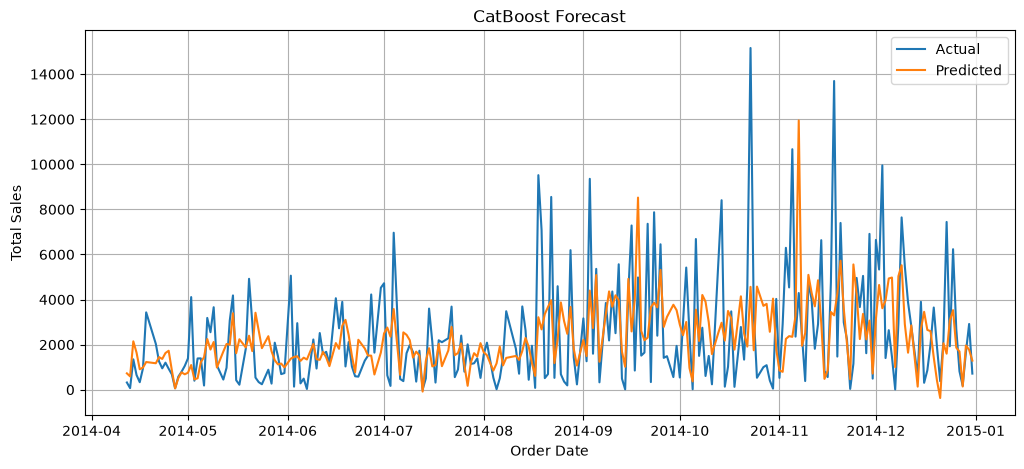

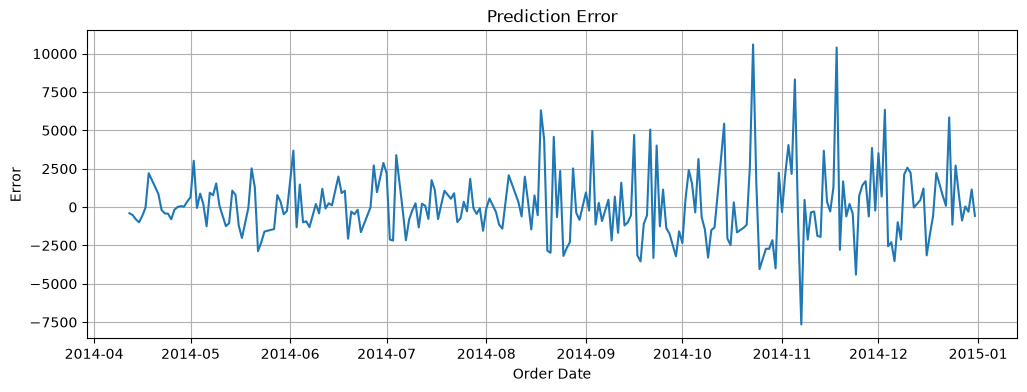

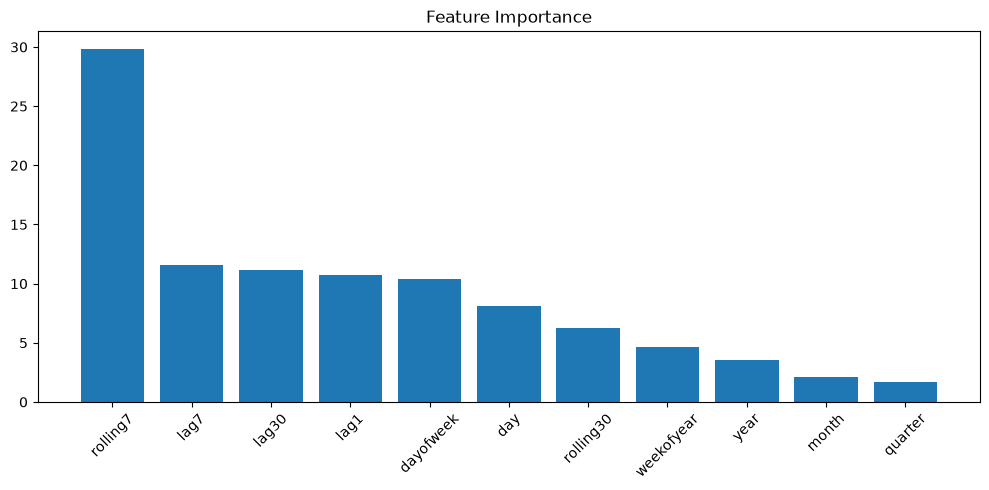

Model saved successfully.


In [ ]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==========================
# Load Dataset
# ==========================
df = pd.read_csv('../../../week1/preprocessing/daily_sales.csv')

df = df[['Order Date', 'Total amount']]
df['Order Date'] = pd.to_datetime(df['Order Date'], format="mixed",dayfirst=True,errors='coerce')

df = (
    df.groupby('Order Date')['Total amount']
    .sum()
    .reset_index()
    .sort_values('Order Date')
    .reset_index(drop=True)
)

# ==========================
# Feature Engineering
# ==========================
df['day'] = df['Order Date'].dt.day
df['month'] = df['Order Date'].dt.month
df['year'] = df['Order Date'].dt.year
df['dayofweek'] = df['Order Date'].dt.dayofweek
df['weekofyear'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['Order Date'].dt.quarter

df['lag1'] = df['Total amount'].shift(1)
df['lag7'] = df['Total amount'].shift(7)
df['lag30'] = df['Total amount'].shift(30)

df['rolling7'] = df['Total amount'].rolling(7).mean()
df['rolling30'] = df['Total amount'].rolling(30).mean()

df = df.dropna().reset_index(drop=True)

# ==========================
# Features
# ==========================
features = [
    'day',
    'month',
    'year',
    'dayofweek',
    'weekofyear',
    'quarter',
    'lag1',
    'lag7',
    'lag30',
    'rolling7',
    'rolling30'
]

X = df[features]
y = df['Total amount']

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

test_dates = df['Order Date'].iloc[split:]

# ==========================
# Train CatBoost Model
# ==========================
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
residuals = y_test - pred
std_errors = np.std(residuals)
print("Standard Deviation of Errors:", std_errors)
confidence_interval = 1.96 * std_errors
print("95% Confidence Margin:", confidence_interval)

# ==========================
# Evaluation
# ==========================
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE :", mae)
print("RMSE:", rmse)

# ==========================
# Actual vs Predicted
# ==========================
plt.figure(figsize=(12,5))
plt.plot(test_dates, y_testP.to_numpy(), label='Actual')
plt.plot(test_dates.to_numpy(), pred, label='Predicted')
plt.title("CatBoost Forecast")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.show()

# ==========================
# Prediction Error
# ==========================
errors = y_test.to_numpy() - pred

plt.figure(figsize=(12,4))
plt.plot(test_dates, errors)
plt.title("Prediction Error")
plt.xlabel("Order Date")
plt.ylabel("Error")
plt.grid(True)
plt.show()

# ==========================
# Feature Importance
# ==========================
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

# ==========================
# Save Model
# ==========================
joblib.dump(model, "catboost_daily_model.pkl")

print("Model saved successfully.")